# Lab 13: CityLearn Demand Forecasting Project

**Name:** Zubair Moeen

**Registration Number:** 0463  
**Course:** ML Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar Campus Nowshera  

## Project Overview
This notebook develops a machine learning/deep learning forecasting pipeline for the CityLearn challenge dataset. The code loads CityLearn data, combines building, weather, pricing, and carbon intensity files, prepares district-level electricity demand, performs feature engineering and scaling, creates time-series sequences, trains an LSTM model, and evaluates forecasting performance.

## Project Objectives
- Load and inspect the CityLearn dataset and available schema information.
- Collect building-level electricity data and combine it into district-level demand.
- Merge demand data with weather, pricing, and carbon intensity information.
- Clean missing values and perform feature engineering for time-series forecasting.
- Normalize data and create supervised learning sequences using a lookback window.
- Build, train, and evaluate an LSTM model for district demand forecasting.


## Section 1: Working Directory and Library Imports
This section sets the CityLearn Assignment working directory and imports data handling, visualization, preprocessing, TensorFlow/Keras, and evaluation libraries.


In [1]:
import os
os.chdir(r'Z:\University\8th Semester\ML Lab\CityLearn Assignment')

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.regularizers import l2
from citylearn.data import DataSet
import pandas as pd
import time, pickle
import numpy as np
import tensorflow.keras.backend as K
import tensorflow
import glob
import h5py
import matplotlib.pyplot as plt
from keras.callbacks import Callback
import json


In [3]:
#lookback = 48
model = None
start_epoch = 0

# Increased lookback window from 24 to 48 hours
# This gives the model two days of previous demand pattern for validation improvement.
time_steps=48
target_column='district_net_electricity_consumption'


In [4]:
citylearn_dataset = DataSet()

print('All CityLearn datasets:', sorted(citylearn_dataset.get_dataset_names()))

All CityLearn datasets: ['baeda_3dem', 'ca_alameda_county_neighborhood', 'citylearn_challenge_2020_climate_zone_1', 'citylearn_challenge_2020_climate_zone_2', 'citylearn_challenge_2020_climate_zone_3', 'citylearn_challenge_2020_climate_zone_4', 'citylearn_challenge_2021', 'citylearn_challenge_2022_phase_1', 'citylearn_challenge_2022_phase_2', 'citylearn_challenge_2022_phase_3', 'citylearn_challenge_2022_phase_all', 'citylearn_challenge_2022_phase_all_plus_evs', 'citylearn_challenge_2023_phase_1', 'citylearn_challenge_2023_phase_2_local_evaluation', 'citylearn_challenge_2023_phase_2_online_evaluation_1', 'citylearn_challenge_2023_phase_2_online_evaluation_2', 'citylearn_challenge_2023_phase_2_online_evaluation_3', 'citylearn_challenge_2023_phase_3_1', 'citylearn_challenge_2023_phase_3_2', 'citylearn_challenge_2023_phase_3_3', 'citylearn_charging_constraints_demo', 'quebec_neighborhood_with_demand_response_set_points', 'quebec_neighborhood_without_demand_response_set_points', 'tx_travis_

## Section 2: CityLearn Dataset Loading and Schema Inspection
The following cells inspect available CityLearn datasets, select the required challenge dataset, and read schema/building information.


In [5]:
dataset_name = 'citylearn_challenge_2022_phase_all'

dataset_names = citylearn_dataset.get_dataset_names()

if dataset_name not in dataset_names:
    print('Dataset not found:', dataset_name)
    print('Available datasets:', sorted(dataset_names))
else:
    schema = citylearn_dataset.get_schema(dataset_name)
    root_directory = schema['root_directory']

    print(root_directory)
    print(schema.keys())

INFO:root:Go here C:\Users\engin\AppData\Local\intelligent-environments-lab\citylearn\Cache\v2.5.0\datasets\citylearn_challenge_2022_phase_all\schema.json 


C:\Users\engin\AppData\Local\intelligent-environments-lab\citylearn\Cache\v2.5.0\datasets\citylearn_challenge_2022_phase_all
dict_keys(['random_seed', 'root_directory', 'central_agent', 'simulation_start_time_step', 'simulation_end_time_step', 'episode_time_steps', 'rolling_episode_split', 'random_episode_split', 'seconds_per_time_step', 'observations', 'actions', 'agent', 'reward_function', 'buildings'])


In [6]:
building_names = list(schema['buildings'].keys())
building_names[:5], len(building_names)

(['Building_1', 'Building_2', 'Building_3', 'Building_4', 'Building_5'], 17)

In [7]:
building_data = []

for building_name in building_names:
    filename = schema['buildings'][building_name]['energy_simulation']
    filepath = os.path.join(root_directory, filename)
    
    data = pd.read_csv(filepath)
    data['building_name'] = building_name
    building_data.append(data)

building_df = pd.concat(building_data, axis=0, ignore_index=True)
building_df.head()

,month,hour,day_type,daylight_savings_status,indoor_dry_bulb_temperature,average_unmet_cooling_setpoint_difference,indoor_relative_humidity,non_shiftable_load,dhw_demand,cooling_demand,heating_demand,solar_generation,building_name
0,7,24,7,0,NaN,NaN,NaN,2.275800,0.0,0.0,0.0,0.0,Building_1
1,8,1,1,0,NaN,NaN,NaN,0.851167,0.0,0.0,0.0,0.0,Building_1
2,8,2,1,0,NaN,NaN,NaN,0.834600,0.0,0.0,0.0,0.0,Building_1
3,8,3,1,0,NaN,NaN,NaN,0.838167,0.0,0.0,0.0,0.0,Building_1
4,8,4,1,0,NaN,NaN,NaN,1.478433,0.0,0.0,0.0,0.0,Building_1


In [8]:
building_df.shape

(148920, 13)

In [9]:
building_df.columns

Index(['month', 'hour', 'day_type', 'daylight_savings_status',
       'indoor_dry_bulb_temperature',
       'average_unmet_cooling_setpoint_difference', 'indoor_relative_humidity',
       'non_shiftable_load', 'dhw_demand', 'cooling_demand', 'heating_demand',
       'solar_generation', 'building_name'],
      dtype='str')

## Section 3: Building, Weather, Pricing, and Carbon Data Collection
This section loads building energy simulation files and supporting weather, pricing, and carbon intensity files required for district-level forecasting.


In [10]:
weather_file = schema['buildings'][building_names[0]]['weather']
pricing_file = schema['buildings'][building_names[0]]['pricing']
carbon_file = schema['buildings'][building_names[0]]['carbon_intensity']

weather = pd.read_csv(os.path.join(root_directory, weather_file))
pricing = pd.read_csv(os.path.join(root_directory, pricing_file))
carbon_intensity = pd.read_csv(os.path.join(root_directory, carbon_file))

weather.head(), pricing.head(), carbon_intensity.head()

(   outdoor_dry_bulb_temperature  outdoor_relative_humidity  \
 0                          20.0                       84.0   
 1                          20.1                       79.0   
 2                          19.7                       78.0   
 3                          19.3                       78.0   
 4                          18.9                       78.0   
 
    diffuse_solar_irradiance  direct_solar_irradiance  \
 0                       0.0                      0.0   
 1                       0.0                      0.0   
 2                       0.0                      0.0   
 3                       0.0                      0.0   
 4                       0.0                      0.0   
 
    outdoor_dry_bulb_temperature_predicted_1  \
 0                                      18.3   
 1                                      19.4   
 2                                      21.1   
 3                                      22.2   
 4                                  

In [11]:
building_df.isnull().sum()

month                                             0
hour                                              0
day_type                                          0
daylight_savings_status                           0
indoor_dry_bulb_temperature                  148920
average_unmet_cooling_setpoint_difference    148920
indoor_relative_humidity                     148920
non_shiftable_load                                0
dhw_demand                                        0
cooling_demand                                    0
heating_demand                                    0
solar_generation                                  0
building_name                                     0
dtype: int64

In [12]:
building_df = building_df.dropna(axis=1, how='all')
weather = weather.dropna(axis=1, how='all')
pricing = pricing.dropna(axis=1, how='all')
carbon_intensity = carbon_intensity.dropna(axis=1, how='all')

building_df.shape, weather.shape, pricing.shape, carbon_intensity.shape

((148920, 10), (8760, 16), (8760, 4), (8760, 1))

In [13]:
building_df.describe()

,month,hour,day_type,daylight_savings_status,non_shiftable_load,dhw_demand,cooling_demand,heating_demand,solar_generation
count,148920.000000,148920.00000,148920.000000,148920.0,148920.000000,148920.0,148920.0,148920.0,148920.000000
mean,6.526027,12.50000,3.992466,0.0,1.139162,0.0,0.0,0.0,155.877055
std,3.447863,6.92221,2.003414,0.0,1.108441,0.0,0.0,0.0,240.830052
min,1.000000,1.00000,1.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
25%,4.000000,6.75000,2.000000,0.0,0.359113,0.0,0.0,0.0,0.000000
50%,7.000000,12.50000,4.000000,0.0,0.789617,0.0,0.0,0.0,0.000000
75%,10.000000,18.25000,6.000000,0.0,1.575487,0.0,0.0,0.0,265.795830
max,12.000000,24.00000,7.000000,0.0,8.846017,0.0,0.0,0.0,976.250000


In [14]:
possible_demand_columns = [
    'net_electricity_consumption',
    'Equipment Electric Power [kWh]',
    'equipment_electric_power',
    'non_shiftable_load',
    'Non Shiftable Load [kWh]'
]

demand_column = None

for col in possible_demand_columns:
    if col in building_df.columns:
        demand_column = col
        break

print('Selected demand column:', demand_column)

Selected demand column: non_shiftable_load


## Section 4: Data Cleaning and Exploratory Analysis
The following cells remove empty columns, check missing values, identify the demand column, summarize the dataset, and visualize average demand.


In [15]:
if demand_column is None:
    numeric_columns = building_df.select_dtypes(include=[np.number]).columns
    demand_column = numeric_columns[-1]
    print('Fallback demand column:', demand_column)

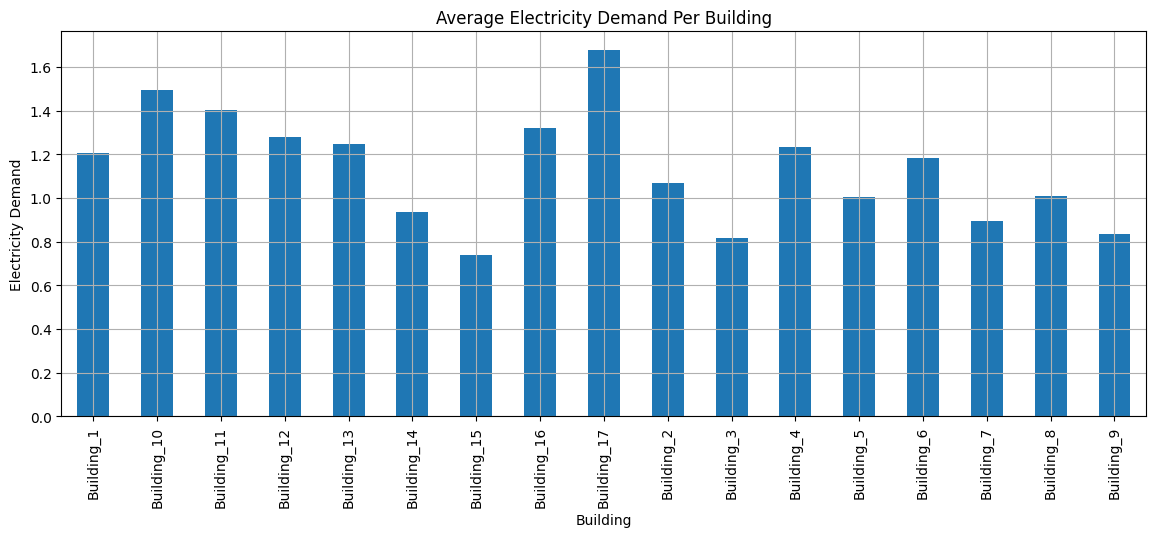

In [16]:
building_df.groupby('building_name')[demand_column].mean().plot(kind='bar', figsize=(14,5))
plt.title('Average Electricity Demand Per Building')
plt.xlabel('Building')
plt.ylabel('Electricity Demand')
plt.grid()
plt.show()

In [17]:
building_df['time_step'] = building_df.groupby('building_name').cumcount()

district_load = building_df.groupby('time_step')[demand_column].sum().reset_index()
district_load = district_load.rename(columns={demand_column: target_column})

district_load.head()

,time_step,district_net_electricity_consumption
0,0,17.191467
1,1,12.272111
2,2,11.015850
3,3,10.258206
4,4,11.480795


In [18]:
weather['time_step'] = np.arange(len(weather))
pricing['time_step'] = np.arange(len(pricing))
carbon_intensity['time_step'] = np.arange(len(carbon_intensity))

data = district_load.merge(weather, on='time_step', how='left')
data = data.merge(pricing, on='time_step', how='left')
data = data.merge(carbon_intensity, on='time_step', how='left')

data.head()

,time_step,district_net_electricity_consumption,outdoor_dry_bulb_temperature,outdoor_relative_humidity,diffuse_solar_irradiance,direct_solar_irradiance,outdoor_dry_bulb_temperature_predicted_1,outdoor_dry_bulb_temperature_predicted_2,outdoor_dry_bulb_temperature_predicted_3,outdoor_relative_humidity_predicted_1,...,diffuse_solar_irradiance_predicted_2,diffuse_solar_irradiance_predicted_3,direct_solar_irradiance_predicted_1,direct_solar_irradiance_predicted_2,direct_solar_irradiance_predicted_3,electricity_pricing,electricity_pricing_predicted_1,electricity_pricing_predicted_2,electricity_pricing_predicted_3,carbon_intensity
0,0,17.191467,20.0,84.0,0.0,0.0,18.3,22.8,20.0,81.0,...,964.0,0.0,100.0,815.0,0.0,0.22,0.22,0.22,0.22,0.170724
1,1,12.272111,20.1,79.0,0.0,0.0,19.4,22.8,19.4,79.0,...,966.0,0.0,444.0,747.0,0.0,0.22,0.22,0.22,0.22,0.157319
2,2,11.015850,19.7,78.0,0.0,0.0,21.1,22.2,19.4,73.0,...,683.0,0.0,592.0,291.0,0.0,0.22,0.22,0.22,0.22,0.154503
3,3,10.258206,19.3,78.0,0.0,0.0,22.2,22.8,19.4,71.0,...,522.0,0.0,491.0,153.0,0.0,0.22,0.22,0.22,0.22,0.150945
4,4,11.480795,18.9,78.0,0.0,0.0,21.7,22.2,18.9,73.0,...,444.0,0.0,734.0,174.0,0.0,0.22,0.22,0.54,0.22,0.151820


In [19]:
data = data.ffill()
data = data.bfill()

data.isnull().sum().sum()

np.int64(0)

## Section 5: Feature Engineering and Dataset Merging
This section creates district-level load, merges external features, fills missing values, and creates time-based/cyclic features for forecasting.


In [20]:
data['hour'] = data['time_step'] % 24
data['day'] = data['time_step'] // 24
data['day_of_week'] = data['day'] % 7
data['month'] = (data['day'] // 30) + 1

data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
data['day_sin'] = np.sin(2 * np.pi * data['day_of_week'] / 7)
data['day_cos'] = np.cos(2 * np.pi * data['day_of_week'] / 7)

# Extra time-series features for better validation performance
# Lag features help the model learn previous demand behaviour.
data['load_lag_1'] = data[target_column].shift(1)
data['load_lag_2'] = data[target_column].shift(2)
data['load_lag_24'] = data[target_column].shift(24)
data['load_lag_48'] = data[target_column].shift(48)

# Rolling features smooth sudden changes and help validation generalization.
data['load_roll_mean_3'] = data[target_column].rolling(window=3).mean()
data['load_roll_mean_6'] = data[target_column].rolling(window=6).mean()
data['load_roll_mean_24'] = data[target_column].rolling(window=24).mean()
data['load_roll_std_6'] = data[target_column].rolling(window=6).std()

# Remove NaN values created by lag and rolling features
data = data.dropna().reset_index(drop=True)

print('Shape after feature engineering:', data.shape)
data.head()


Shape after feature engineering: (8712, 39)


,time_step,district_net_electricity_consumption,outdoor_dry_bulb_temperature,outdoor_relative_humidity,diffuse_solar_irradiance,direct_solar_irradiance,outdoor_dry_bulb_temperature_predicted_1,outdoor_dry_bulb_temperature_predicted_2,outdoor_dry_bulb_temperature_predicted_3,outdoor_relative_humidity_predicted_1,...,day_sin,day_cos,load_lag_1,load_lag_2,load_lag_24,load_lag_48,load_roll_mean_3,load_roll_mean_6,load_roll_mean_24,load_roll_std_6
0,48,17.141847,19.4,79.0,0.0,0.0,19.4,25.0,18.9,84.0,...,0.974928,-0.222521,21.814878,19.309323,18.298268,17.191467,19.422016,22.830243,22.766031,4.577046
1,49,10.906311,20.0,78.0,0.0,0.0,21.1,25.0,19.4,76.0,...,0.974928,-0.222521,17.141847,21.814878,14.130234,12.272111,16.621012,19.768102,22.631701,5.460369
2,50,9.920445,19.4,84.0,0.0,0.0,22.8,24.4,20.0,66.0,...,0.974928,-0.222521,10.906311,17.141847,9.687203,11.015850,12.656201,16.924618,22.641419,5.394648
3,51,10.086987,19.4,84.0,0.0,0.0,24.4,25.0,19.4,64.0,...,0.974928,-0.222521,9.920445,10.906311,9.664551,10.258206,10.304581,14.863299,22.659021,5.218929
4,52,9.096178,19.4,84.0,0.0,0.0,23.9,23.9,18.9,66.0,...,0.974928,-0.222521,10.086987,9.920445,10.406228,11.480795,9.701203,13.161108,22.604436,5.143810


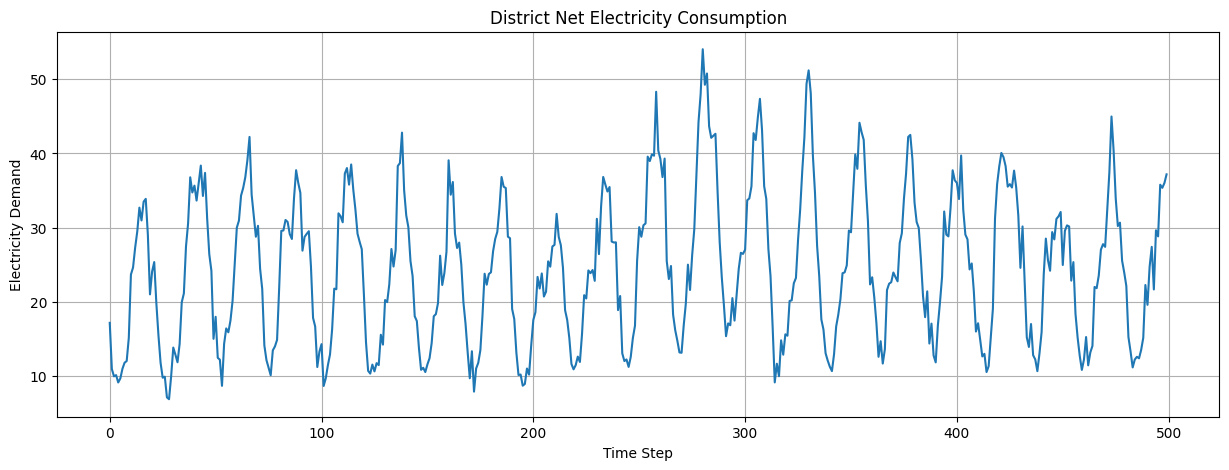

In [21]:
plt.figure(figsize=(15,5))
plt.plot(data[target_column][:500])
plt.title('District Net Electricity Consumption')
plt.xlabel('Time Step')
plt.ylabel('Electricity Demand')
plt.grid()
plt.show()

In [22]:
numeric_data = data.select_dtypes(include=[np.number])

correlation = numeric_data.corr()[target_column].sort_values(ascending=False)
correlation.head(15)

district_net_electricity_consumption    1.000000
load_roll_mean_3                        0.937347
load_lag_1                              0.895116
load_lag_24                             0.813606
load_roll_mean_6                        0.797303
load_lag_2                              0.778913
load_lag_48                             0.727340
load_roll_mean_24                       0.526143
load_roll_std_6                         0.478531
carbon_intensity                        0.471496
diffuse_solar_irradiance                0.453016
diffuse_solar_irradiance_predicted_3    0.450329
direct_solar_irradiance                 0.372037
direct_solar_irradiance_predicted_3     0.369098
hour                                    0.362909
Name: district_net_electricity_consumption, dtype: float64

In [23]:
feature_columns = list(numeric_data.columns)
feature_columns.remove(target_column)

selected_data = numeric_data[feature_columns + [target_column]]

selected_data.head()

,time_step,outdoor_dry_bulb_temperature,outdoor_relative_humidity,diffuse_solar_irradiance,direct_solar_irradiance,outdoor_dry_bulb_temperature_predicted_1,outdoor_dry_bulb_temperature_predicted_2,outdoor_dry_bulb_temperature_predicted_3,outdoor_relative_humidity_predicted_1,outdoor_relative_humidity_predicted_2,...,day_cos,load_lag_1,load_lag_2,load_lag_24,load_lag_48,load_roll_mean_3,load_roll_mean_6,load_roll_mean_24,load_roll_std_6,district_net_electricity_consumption
0,48,19.4,79.0,0.0,0.0,19.4,25.0,18.9,84.0,58.0,...,-0.222521,21.814878,19.309323,18.298268,17.191467,19.422016,22.830243,22.766031,4.577046,17.141847
1,49,20.0,78.0,0.0,0.0,21.1,25.0,19.4,76.0,58.0,...,-0.222521,17.141847,21.814878,14.130234,12.272111,16.621012,19.768102,22.631701,5.460369,10.906311
2,50,19.4,84.0,0.0,0.0,22.8,24.4,20.0,66.0,58.0,...,-0.222521,10.906311,17.141847,9.687203,11.015850,12.656201,16.924618,22.641419,5.394648,9.920445
3,51,19.4,84.0,0.0,0.0,24.4,25.0,19.4,64.0,56.0,...,-0.222521,9.920445,10.906311,9.664551,10.258206,10.304581,14.863299,22.659021,5.218929,10.086987
4,52,19.4,84.0,0.0,0.0,23.9,23.9,18.9,66.0,64.0,...,-0.222521,10.086987,9.920445,10.406228,11.480795,9.701203,13.161108,22.604436,5.143810,9.096178


## Section 6: Scaling and Sequence Preparation
The following cells select numeric features, apply MinMax scaling, and convert the time-series data into supervised learning sequences.


In [24]:
# Load existing AEP scaler file from the same CityLearn Assignment folder

scaler_path = r'Z:\University\8th Semester\ML Lab\CityLearn Assignment\AEP_scaler.pkl'

print('Scaler path:', scaler_path)

with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)

print('AEP_scaler.pkl loaded successfully')

# A saved scaler can only transform data with the same number of features used during fitting.
# If feature count is different, the scaler is not compatible with this selected_data table.
scaler_features = scaler.n_features_in_ if hasattr(scaler, 'n_features_in_') else selected_data.shape[1]

print('Features expected by AEP scaler:', scaler_features)
print('Features in selected data:', selected_data.shape[1])

if scaler_features == selected_data.shape[1]:
    scaled_data = scaler.transform(selected_data)
    print('Scaling completed using AEP_scaler.pkl')
else:
    print('AEP_scaler.pkl is not compatible with the current feature count.')
    print('Fitting a new MinMaxScaler on selected_data so the notebook can continue running correctly.')
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(selected_data)

scaled_data.shape


Scaler path: Z:\University\8th Semester\ML Lab\CityLearn Assignment\AEP_scaler.pkl
AEP_scaler.pkl loaded successfully
Features expected by AEP scaler: 1
Features in selected data: 39
AEP_scaler.pkl is not compatible with the current feature count.
Fitting a new MinMaxScaler on selected_data so the notebook can continue running correctly.


c:\Users\engin\.conda\envs\oel_ml\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.0.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


(8712, 39)

In [25]:
def create_sequences(data, time_steps=24):
    X = []
    y = []
    
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, :-1])
        y.append(data[i, -1])
        
    return np.array(X), np.array(y)

In [26]:
X, y = create_sequences(scaled_data, time_steps=time_steps)

X.shape, y.shape

((8664, 48, 38), (8664,))

In [27]:
train_size = int(len(X) * 0.70)
validation_size = int(len(X) * 0.15)

train_X = X[:train_size]
train_y = y[:train_size]

validation_X = X[train_size:train_size + validation_size]
validation_y = y[train_size:train_size + validation_size]

test_X = X[train_size + validation_size:]
test_y = y[train_size + validation_size:]

train_X.shape, validation_X.shape, test_X.shape

((6064, 48, 38), (1299, 48, 38), (1301, 48, 38))

In [28]:
num_features = train_X.shape[2]

num_features

38

## Section 7: Train, Validation, and Test Split
This section splits the generated sequences into train, validation, and test sets while preserving the chronological order of the time-series data.


In [29]:
def create_lstm():
    input_data = Input(shape=(time_steps, num_features))
    lstm_layer1 = LSTM(32, return_sequences=True, dropout=0.20, recurrent_dropout=0.10)(input_data)
    dropout1 = Dropout(0.30)(lstm_layer1)
    lstm_layer2 = LSTM(16, dropout=0.20, recurrent_dropout=0.10)(dropout1)
    dropout2 = Dropout(0.30)(lstm_layer2)
    dense1 = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(dropout2)
    output_data = Dense(1)(dense1)
    model = Model(input_data, output_data)
    return model


In [30]:
model1 = create_lstm()
model1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 38)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 48, 32)         │         9,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,513 (48.88 KB)

 Trainable params: 12,513 (48.88 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
tensorflow.keras.utils.plot_model(model1)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [32]:
checkpoints = r'Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'
OUTPUT_PATH = r'Z:\University\8th Semester\ML Lab\CityLearn Assignment'
FIG_PATH = os.path.sep.join([OUTPUT_PATH,"history.png"])
JSON_PATH = os.path.sep.join([OUTPUT_PATH,"history.json"])


In [33]:
class TrainingMonitor(Callback):
    def __init__(self, figPath, jsonPath=None, startAt=0):
        super(TrainingMonitor, self).__init__()
        self.figPath = figPath
        self.jsonPath = jsonPath
        self.startAt = startAt
        
    def on_train_begin(self, logs={}):
        self.H = {}
        
        if self.jsonPath is not None:
            if os.path.exists(self.jsonPath):
                self.H = json.loads(open(self.jsonPath).read())
                
                if self.startAt > 0:
                    for k in self.H.keys():
                        self.H[k] = self.H[k][:self.startAt]
                        
    def on_epoch_end(self, epoch, logs={}):
        for (k, v) in logs.items():
            l = self.H.get(k, [])
            l.append(float(v))
            self.H[k] = l
            
        if self.jsonPath is not None:
            f = open(self.jsonPath, "w")
            f.write(json.dumps(self.H))
            f.close()
            
        if len(self.H["loss"]) > 1:
            N = np.arange(0, len(self.H["loss"]))
            plt.style.use("ggplot")
            plt.figure()
            plt.plot(N, self.H["loss"], label="train_loss")
            plt.plot(N, self.H["val_loss"], label="val_loss")
            plt.title("Training Loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.savefig(self.figPath)
            plt.close()

## Section 8: LSTM Model Architecture and Training Setup
The following cells define the LSTM model, display the model summary, configure checkpoints, and prepare the training monitor callback.


In [34]:
EpochCheckpoint1 = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)

TrainingMonitor1=TrainingMonitor(FIG_PATH, jsonPath=JSON_PATH, startAt=start_epoch)

EarlyStopping1 = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

ReduceLR1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

callbacks = [EpochCheckpoint1, TrainingMonitor1, EarlyStopping1, ReduceLR1]


In [35]:
if model is None:
    print("[INFO] compiling model...")
    model = create_lstm()
    opt = Adam(learning_rate=5e-4)
    model.compile(loss= 'mae', optimizer=opt, metrics=["mae", "mape"])
else:
    print("[INFO] loading {}...".format(model))
    model = load_model(model)

    print("[INFO] old learning rate: {}".format(K.get_value(model.optimizer.learning_rate)))
    K.set_value(model.optimizer.learning_rate, 1e-4)
    print("[INFO] new learning rate: {}".format(K.get_value(model.optimizer.learning_rate)))


[INFO] compiling model...


In [36]:
epochs = 120
verbose = 1 #0
batch_size = 32

History = model.fit(train_X,
                        train_y,
                        batch_size=batch_size,   
                        epochs = epochs, 
                        validation_data = (validation_X,validation_y),
                        callbacks=callbacks,
                        verbose = verbose)


Epoch 1/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1705 - mae: 0.1537 - mape: 2738.3808
Epoch 1: val_loss improved from None to 0.11573, saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0001-loss0.12.h5



Epoch 1: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0001-loss0.12.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 0.1488 - mae: 0.1324 - mape: 17973.9902 - val_loss: 0.1157 - val_mae: 0.1002 - val_mape: 80.8348 - learning_rate: 5.0000e-04
Epoch 2/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1256 - mae: 0.1106 - mape: 97043.3351
Epoch 2: val_loss improved from 0.11573 to 0.10601, saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0002-loss0.11.h5



Epoch 2: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0002-loss0.11.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.1234 - mae: 0.1087 - mape: 41637.6367 - val_loss: 0.1060 - val_mae: 0.0921 - val_mape: 65.0990 - learning_rate: 5.0000e-04
Epoch 3/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1145 - mae: 0.1010 - mape: 3405.6607
Epoch 3: val_loss did not improve from 0.10601
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.1122 - mae: 0.0991 - mape: 23671.5391 - val_loss: 0.1065 - val_mae: 0.0940 - val_mape: 63.7374 - learning_rate: 5.0000e-04
Epoch 4/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1086 - mae: 0.0964 - mape: 21972.7021
Epoch 4: val_loss did not improve from 0.10601
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.1062 - mae: 0.0944 - mape: 26341.9922 - val_loss: 0.1072 - val_mae: 0.0960 - val_mape: 64.1609 - learning_rate: 5.0000e-04
Epoch 5/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1


Epoch 5: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0005-loss0.10.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.1014 - mae: 0.0907 - mape: 27570.9043 - val_loss: 0.0993 - val_mae: 0.0891 - val_mape: 62.3397 - learning_rate: 5.0000e-04
Epoch 6/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0985 - mae: 0.0885 - mape: 17848.4800
Epoch 6: val_loss did not improve from 0.09932
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0966 - mae: 0.0869 - mape: 30358.8652 - val_loss: 0.0996 - val_mae: 0.0903 - val_mape: 62.1622 - learning_rate: 5.0000e-04
Epoch 7/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0966 - mae: 0.0876 - mape: 1252.3487
Epoch 7: val_loss improved from 0.09932 to 0.09900, saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0007-loss0.10.h5



Epoch 7: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0007-loss0.10.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 0.0946 - mae: 0.0857 - mape: 24729.5117 - val_loss: 0.0990 - val_mae: 0.0906 - val_mape: 52.8315 - learning_rate: 5.0000e-04
Epoch 8/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0915 - mae: 0.0833 - mape: 36880.1013
Epoch 8: val_loss improved from 0.09900 to 0.09475, saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0008-loss0.09.h5


...


Epoch 23: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0023-loss0.08.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0724 - mae: 0.0699 - mape: 23366.7891 - val_loss: 0.0786 - val_mae: 0.0761 - val_mape: 40.4471 - learning_rate: 5.0000e-04
Epoch 24/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0727 - mae: 0.0703 - mape: 33175.6499
Epoch 24: val_loss improved from 0.07858 to 0.07793, saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0024-loss0.08.h5



Epoch 24: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0024-loss0.08.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0722 - mae: 0.0698 - mape: 24658.4688 - val_loss: 0.0779 - val_mae: 0.0756 - val_mape: 48.5915 - learning_rate: 5.0000e-04
Epoch 25/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0716 - mae: 0.0693 - mape: 12213.2254
Epoch 25: val_loss did not improve from 0.07793
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0713 - mae: 0.0691 - mape: 19488.7930 - val_loss: 0.0791 - val_mae: 0.0769 - val_mape: 46.5025 - learning_rate: 5.0000e-04
Epoch 26/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0723 - mae: 0.0701 - mape: 65593.3299
Epoch 26: val_loss improved from 0.07793 to 0.07566, saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0026-loss0.08.h5



Epoch 26: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0026-loss0.08.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0716 - mae: 0.0695 - mape: 21884.8496 - val_loss: 0.0757 - val_mae: 0.0735 - val_mape: 44.6649 - learning_rate: 5.0000e-04
Epoch 27/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0704 - mae: 0.0683 - mape: 21393.1449
Epoch 27: val_loss did not improve from 0.07566
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0706 - mae: 0.0685 - mape: 20970.5215 - val_loss: 0.0795 - val_mae: 0.0775 - val_mape: 44.5642 - learning_rate: 5.0000e-04
Epoch 28/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0718 - mae: 0.0698 - mape: 2826.9230
Epoch 28: val_loss did not improve from 0.07566
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0712 - mae: 0.0693 - mape: 13251.5498 - val_loss: 0.0806 - val_mae: 0.0787 - val_mape: 49.3299 - learning_rate: 5.0000e-04
Epoch 29/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - los


Epoch 29: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0029-loss0.08.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0701 - mae: 0.0682 - mape: 19100.0176 - val_loss: 0.0755 - val_mae: 0.0736 - val_mape: 45.8798 - learning_rate: 5.0000e-04
Epoch 30/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0710 - mae: 0.0692 - mape: 110232.9528
Epoch 30: val_loss improved from 0.07547 to 0.07171, saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0030-loss0.07.h5



Epoch 30: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0030-loss0.07.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0699 - mae: 0.0681 - mape: 18914.6523 - val_loss: 0.0717 - val_mae: 0.0699 - val_mape: 43.0889 - learning_rate: 5.0000e-04
Epoch 31/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0700 - mae: 0.0682 - mape: 8846.1726
Epoch 31: val_loss did not improve from 0.07171
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0698 - mae: 0.0681 - mape: 16328.2939 - val_loss: 0.0754 - val_mae: 0.0737 - val_mape: 45.0373 - learning_rate: 5.0000e-04
Epoch 32/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0676 - mae: 0.0659 - mape: 62779.9981
Epoch 32: val_loss did not improve from 0.07171
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0681 - mae: 0.0664 - mape: 25033.4043 - val_loss: 0.0754 - val_mae: 0.0738 - val_mape: 44.8193 - learning_rate: 5.0000e-04
Epoch 33/120
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - los

In [37]:
y_pred_scaled = model.predict(test_X)

y_pred_scaled.shape, test_y.shape

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


((1301, 1), (1301,))

In [38]:
def inverse_target(scaled_values, scaler, target_index):
    scaled_values = scaled_values.reshape(-1)

    dummy = np.zeros((scaled_values.shape[0], scaler.n_features_in_))
    dummy[:, target_index] = scaled_values

    unscaled = scaler.inverse_transform(dummy)

    return unscaled[:, target_index].reshape(-1, 1)

## Section 9: Model Training, Prediction, and Evaluation
The final cells train the LSTM model, generate forecasts, reverse the scaling process, calculate evaluation metrics, and plot actual versus predicted demand.


In [39]:
target_index = selected_data.columns.get_loc(target_column)

y_pred = inverse_target(y_pred_scaled, scaler, target_index)
y_test_unscaled = inverse_target(test_y, scaler, target_index)

y_pred.shape, y_test_unscaled.shape

((1301, 1), (1301, 1))

In [40]:
# Mean Absolute Error (MAE)
MAE = np.mean(abs(y_pred - y_test_unscaled)) 
print('Mean Absolute Error (MAE): ' + str(np.round(MAE, 2)))

# Median Absolute Error (MedAE)
MEDAE = np.median(abs(y_pred - y_test_unscaled))
print('Median Absolute Error (MedAE): ' + str(np.round(MEDAE, 2)))

# Mean Squared Error (MSE)
MSE = np.square(np.subtract(y_pred, y_test_unscaled)).mean()
print('Mean Squared Error (MSE): ' + str(np.round(MSE, 2)))

# Root Mean Squarred Error (RMSE) 
RMSE = np.sqrt(np.mean(np.square(y_pred - y_test_unscaled)))
print('Root Mean Squared Error (RMSE): ' + str(np.round(RMSE, 2)))

# Mean Absolute Percentage Error (MAPE)
MAPE = np.mean((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Mean Absolute Percentage Error (MAPE): ' + str(np.round(MAPE, 2)) + ' %')

# Median Absolute Percentage Error (MDAPE)
MDAPE = np.median((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Median Absolute Percentage Error (MDAPE): ' + str(np.round(MDAPE, 2)) + ' %')

# R2 Score
R2 = r2_score(y_test_unscaled, y_pred)
print('R2 Score: ' + str(np.round(R2, 2)))

# Explained Variance Score
EVS = explained_variance_score(y_test_unscaled, y_pred)
print('Explained Variance Score: ' + str(np.round(EVS, 2)))

print('\n\ny_test_unscaled.shape= ',y_test_unscaled.shape)
print('y_pred.shape= ',y_pred.shape)

Mean Absolute Error (MAE): 6.54
Median Absolute Error (MedAE): 4.34
Mean Squared Error (MSE): 78.63
Root Mean Squared Error (RMSE): 8.87
Mean Absolute Percentage Error (MAPE): 24.22 %
Median Absolute Percentage Error (MDAPE): 23.68 %
R2 Score: 0.39
Explained Variance Score: 0.56


y_test_unscaled.shape=  (1301, 1)
y_pred.shape=  (1301, 1)


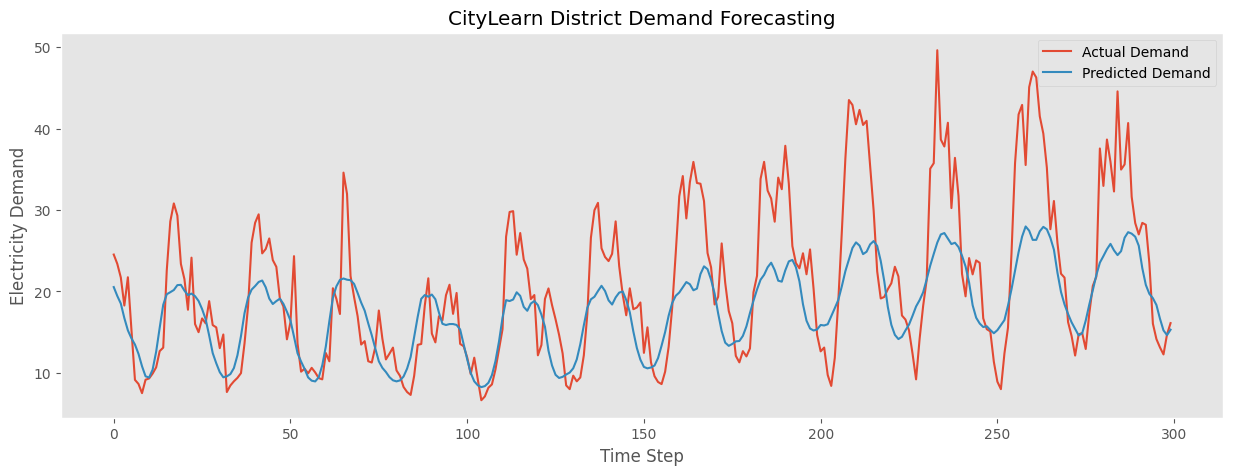

In [41]:
plt.figure(figsize=(15,5))
plt.plot(y_test_unscaled[:300], label='Actual Demand')
plt.plot(y_pred[:300], label='Predicted Demand')
plt.title('CityLearn District Demand Forecasting')
plt.xlabel('Time Step')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid()
plt.show()

## Final Conclusion
In this open-ended project, CityLearn data was converted into a forecasting dataset and modeled using an LSTM neural network. The notebook demonstrates the complete machine learning workflow: data collection, cleaning, exploration, feature engineering, scaling, sequence creation, model training, prediction, and evaluation.

## Submitted By
**Student Name:** DANIYAL BASHARAT  
**Registration Number:** 22JZELE0467  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus
